In [16]:
# Dependencies
library(here)
library(ggplot2)
library(dplyr)
library(leaps)
library(tidyr)
library(corrplot)
library(car)
library(MASS)
library(MuMIn)
library(caret)

Loading required package: lattice



In [10]:
# Load data
df <- read.csv(here("data", "death_rate_nb.csv"))
head(df)

,state,year,deaths,death_rate,hydro_gms,oxy_gms,fent_gms,pop,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,log_pop,log_hydro,log_oxy,log_fent,log_death_rate
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AL,2000,197,-1.308400,-0.1037009,-0.07198984,-0.08602873,-0.2396840,-0.73962867,0.1942059,-0.38573312,-0.62386327,-1.6618041,-1.026754,15.30890,-0.3974345,-0.9192862,-0.9234053,-1.787006
2,AL,2001,216,-1.241686,-0.1035686,-0.07195101,-0.08602885,-0.2373706,-0.49287538,0.9488591,-0.31689900,-0.18631157,-1.6108019,-1.026754,15.31237,-0.3637661,-0.8364945,-0.9250998,-1.627562
3,AL,2002,211,-1.262992,-0.1032225,-0.07193209,-0.08601729,-0.2355071,-0.13312766,0.5559496,-0.16282797,0.06299210,-1.5138153,-1.026754,15.31515,-0.2837199,-0.8000439,-0.7838532,-1.677258
4,AL,2003,197,-1.317015,-0.1028859,-0.07191409,-0.08600594,-0.2320056,-0.07274793,0.6885560,-0.03373072,0.09102397,-1.4083021,-1.026754,15.32036,-0.2149542,-0.7673390,-0.6757568,-1.808450
5,AL,2004,283,-1.001213,-0.1025557,-0.07189656,-0.08599476,-0.2279301,-0.22717372,1.3322157,0.07729171,0.21132943,-1.1632969,-1.026754,15.32639,-0.1543956,-0.7371711,-0.5882937,-1.132110
6,AL,2005,283,-1.004699,-0.1022392,-0.07188020,-0.08598392,-0.2220834,-0.83051811,1.2020409,0.35266288,0.28930908,-0.9977787,-1.026754,15.33498,-0.1015865,-0.7103351,-0.5160579,-1.138560


In [11]:
mod_nb <- glm.nb(deaths ~ log_oxy + log_fent + log_hydro +
                   snap_rate + unempl_rate + poverty_rate +
                   medicaid_rate + gsp_per_cap + min_wage +
                   offset(log_pop),
                 data = df)
summary(mod_nb)

exp(coef(mod_nb))


Call:
glm.nb(formula = deaths ~ log_oxy + log_fent + log_hydro + snap_rate + 
    unempl_rate + poverty_rate + medicaid_rate + gsp_per_cap + 
    min_wage + offset(log_pop), data = df, init.theta = 7.799485166, 
    link = log)

Coefficients:
               Estimate Std. Error  z value Pr(>|z|)    
(Intercept)   -9.044551   0.012466 -725.538  < 2e-16 ***
log_oxy        0.141626   0.020550    6.892 5.51e-12 ***
log_fent       0.032380   0.016134    2.007 0.044750 *  
log_hydro     -0.066987   0.020738   -3.230 0.001237 ** 
snap_rate      0.125751   0.025286    4.973 6.59e-07 ***
unempl_rate   -0.009268   0.014999   -0.618 0.536618    
poverty_rate   0.028673   0.021162    1.355 0.175442    
medicaid_rate  0.017849   0.018930    0.943 0.345754    
gsp_per_cap    0.055024   0.017623    3.122 0.001794 ** 
min_wage       0.080240   0.020848    3.849 0.000119 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.7995) family ta

(Intercept)       log_oxy      log_fent     log_hydro     snap_rate 
 0.0001180325  1.1521452545  1.0329099933  0.9352070542  1.1339998246 
  unempl_rate  poverty_rate medicaid_rate   gsp_per_cap      min_wage 
 0.9907746518  1.0290875711  1.0180088052  1.0565658765  1.0835475211

In [12]:
options(na.action = "na.fail") 

global_nb <- glm.nb(deaths ~ log_oxy + log_fent + log_hydro + 
                    snap_rate + unempl_rate + poverty_rate + 
                    medicaid_rate + gsp_per_cap + min_wage + 
                    offset(log_pop), 
                    data = df)

# 2. Run the automated selection (testing all 512 combinations)
model_set <- dredge(global_nb, rank = "AICc")

# 3. View the top models
head(model_set)

# 4. Extract the single 'Best' model
best_nb_model <- get.models(model_set, 1)[[1]]
summary(best_nb_model)

Fixed term is "(Intercept)"

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


,(Intercept),gsp_per_cap,log_fent,log_hydro,log_oxy,medicaid_rate,min_wage,poverty_rate,snap_rate,unempl_rate,offset(log_pop),df,logLik,AICc,delta,weight
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<mdl.wght>
752,-9.044434,0.05781685,0.03148151,-0.07155859,0.1423316,NA,0.08063618,0.03004516,0.1363688,NA,+,9,-5488.213,10994.64,0.0000000,0.2185501
688,-9.044213,0.05129279,0.02910409,-0.06445138,0.1374840,NA,0.07617443,NA,0.1593374,NA,+,8,-5489.302,10994.77,0.1339188,0.2043953
704,-9.044384,0.04947849,0.03085575,-0.06184998,0.1372853,0.02562575,0.07195924,NA,0.1407811,NA,+,9,-5488.315,10994.85,0.2042611,0.1973314
768,-9.044540,0.05532621,0.03255698,-0.06829374,0.1414131,0.02121937,0.07645927,0.02545908,0.1244965,NA,+,10,-5487.564,10995.39,0.7486229,0.1503106
1008,-9.044474,0.05683129,0.03147976,-0.06895392,0.1424182,NA,0.08506442,0.03359129,0.1354562,-0.01321917,+,10,-5487.799,10995.86,1.2195421,0.1187766
686,-9.043938,0.04740548,NA,-0.05477016,0.1484367,NA,0.08335240,NA,0.1551906,NA,+,7,-5490.935,10996.00,1.3615396,0.1106360



Call:
glm.nb(formula = deaths ~ gsp_per_cap + log_fent + log_hydro + 
    log_oxy + min_wage + poverty_rate + snap_rate + offset(log_pop) + 
    1, data = df, init.theta = 7.781909897, link = log)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept)  -9.04443    0.01248 -724.734  < 2e-16 ***
gsp_per_cap   0.05782    0.01753    3.298 0.000973 ***
log_fent      0.03148    0.01613    1.952 0.050931 .  
log_hydro    -0.07156    0.02056   -3.481 0.000500 ***
log_oxy       0.14233    0.02057    6.919 4.56e-12 ***
min_wage      0.08064    0.01969    4.094 4.23e-05 ***
poverty_rate  0.03005    0.02033    1.478 0.139429    
snap_rate     0.13637    0.02353    5.795 6.84e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.7819) family taken to be 1)

    Null deviance: 1434.66  on 849  degrees of freedom
Residual deviance:  879.69  on 842  degrees of freedom
AIC: 10994

Number of Fisher Scoring it

In [14]:
# Ideal NB Regression Model
nbmod <- glm.nb(deaths ~ log_oxy + log_hydro + log_fent +
                  snap_rate + min_wage + gsp_per_cap +
                  offset(log_pop),
                data = df)
summary(nbmod)


Call:
glm.nb(formula = deaths ~ log_oxy + log_hydro + log_fent + snap_rate + 
    min_wage + gsp_per_cap + offset(log_pop), data = df, init.theta = 7.764013125, 
    link = log)

Coefficients:
            Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -9.04421    0.01249 -723.941  < 2e-16 ***
log_oxy      0.13748    0.02043    6.728 1.72e-11 ***
log_hydro   -0.06445    0.01999   -3.223  0.00127 ** 
log_fent     0.02910    0.01606    1.812  0.06998 .  
snap_rate    0.15934    0.01792    8.890  < 2e-16 ***
min_wage     0.07617    0.01947    3.913 9.12e-05 ***
gsp_per_cap  0.05129    0.01707    3.006  0.00265 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.764) family taken to be 1)

    Null deviance: 1431.50  on 849  degrees of freedom
Residual deviance:  879.94  on 843  degrees of freedom
AIC: 10995

Number of Fisher Scoring iterations: 1


              Theta:  7.764 
          Std. Err.:  0.386 

 2 x log-l

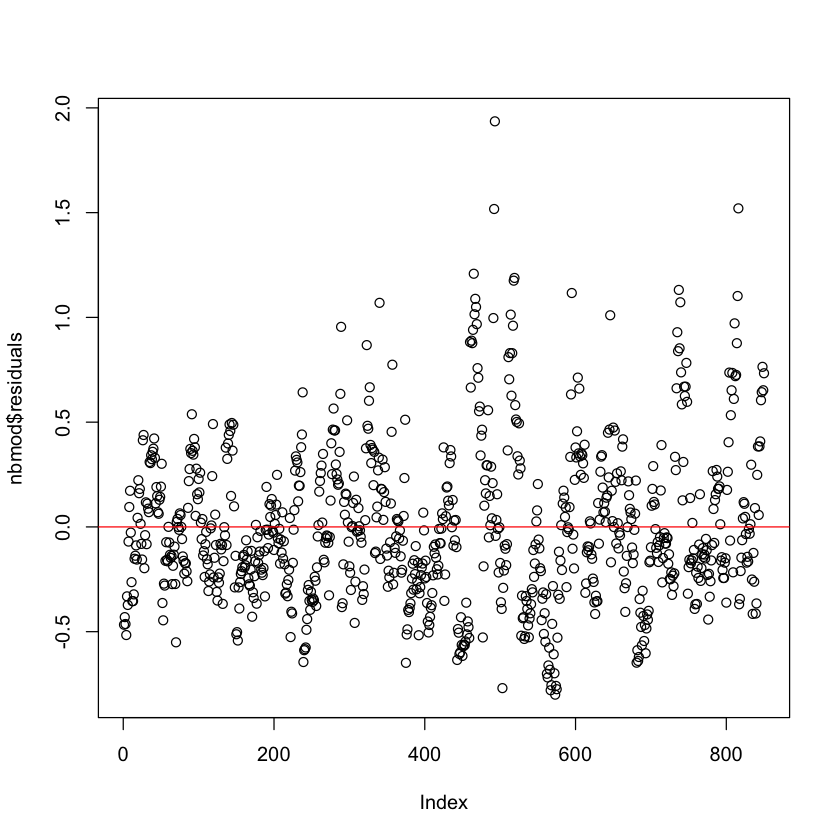

In [15]:
# Check Deviance Residuals
plot(nbmod$residuals)
abline(h = 0, col = "red")

#### Training/Testing Split

In [17]:
set.seed(123)

train_idx <- createDataPartition(df$deaths, p = 0.8, list = FALSE)
train <- df[train_idx, ]
test <- df[-train_idx, ]

In [18]:
nb_train <- glm.nb(deaths ~ log_oxy + log_hydro + log_fent +
                     snap_rate + min_wage + gsp_per_cap +
                     offset(log_pop),
                   data = train)
summary(nb_train)


Call:
glm.nb(formula = deaths ~ log_oxy + log_hydro + log_fent + snap_rate + 
    min_wage + gsp_per_cap + offset(log_pop), data = train, init.theta = 7.575735958, 
    link = log)

Coefficients:
            Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -9.04848    0.01413 -640.485  < 2e-16 ***
log_oxy      0.13072    0.02256    5.795 6.83e-09 ***
log_hydro   -0.05609    0.02176   -2.578 0.009947 ** 
log_fent     0.02555    0.01759    1.452 0.146372    
snap_rate    0.16301    0.02077    7.849 4.19e-15 ***
min_wage     0.07892    0.02241    3.523 0.000427 ***
gsp_per_cap  0.04787    0.01932    2.477 0.013231 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.5757) family taken to be 1)

    Null deviance: 1143.92  on 681  degrees of freedom
Residual deviance:  704.82  on 675  degrees of freedom
AIC: 8837.9

Number of Fisher Scoring iterations: 1


              Theta:  7.576 
          Std. Err.:  0.420 

 2 x 

In [19]:
# Predict count on test set
predictions <- predict(nb_train, newdata = test, type = "response")

# Compare to actuals
results <- data.frame(
  Actual = test$deaths,
  Predicted = predictions
)

# Calculate Accuracy Metrics
rmse <- sqrt(mean((results$Actual - results$Predicted)^2))
mae <- mean(abs(results$Actual - results$Predicted))
test_r2 <- cor(results$Actual, results$Predicted)^2

cat(paste0("RMSE: ", rmse, "\n", "Mean Absolute Error (MAE): ", mae, "\n",
           "Test R2: ", test_r2))

RMSE: 296.017548607156
Mean Absolute Error (MAE): 165.561148922597
Test R2: 0.862731014825483

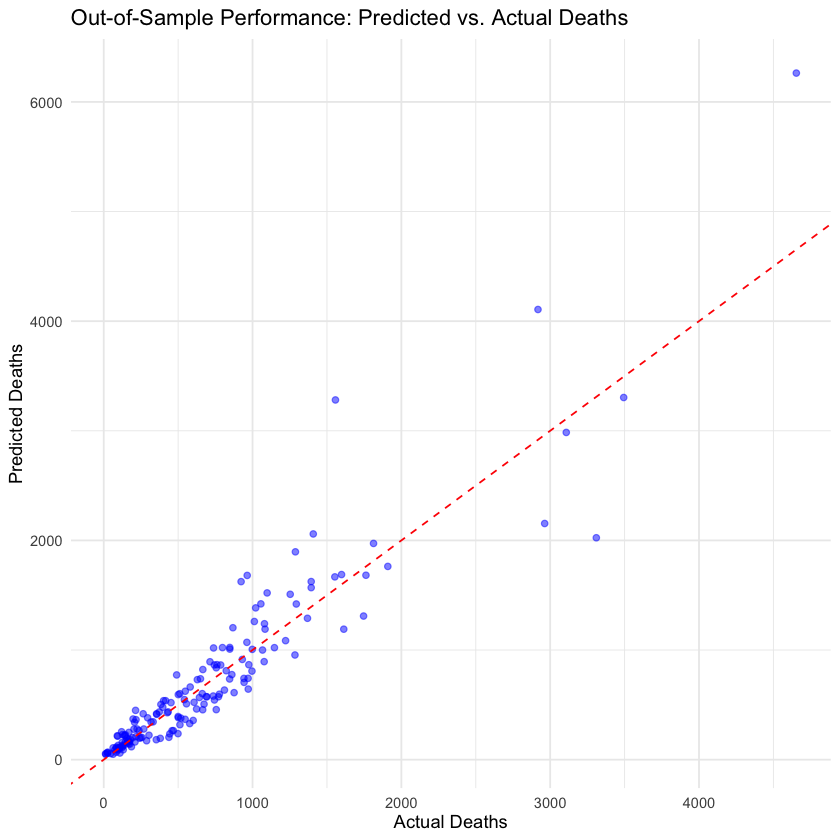

In [20]:
library(ggplot2)

ggplot(results, aes(x = Actual, y = Predicted)) +
  geom_point(alpha = 0.5, color = "blue") +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  labs(title = "Out-of-Sample Performance: Predicted vs. Actual Deaths",
       x = "Actual Deaths",
       y = "Predicted Deaths") +
  theme_minimal()

In [21]:
# Try again, remove log_hydro
nb_train_red <- glm.nb(deaths ~ log_oxy + log_fent +
                         snap_rate + min_wage + gsp_per_cap +
                         offset(log_pop),
                       data = train)
summary(nb_train_red)

# Predict count on test set
predictions <- predict(nb_train_red, newdata = test, type = "response")

# Compare to actuals
results <- data.frame(
  Actual = test$deaths,
  Predicted = predictions
)

# Calculate Accuracy Metrics
rmse <- sqrt(mean((results$Actual - results$Predicted)^2))
mae <- mean(abs(results$Actual - results$Predicted))
test_r2 <- cor(results$Actual, results$Predicted)^2

cat(paste0("RMSE: ", rmse, "\n", "Mean Absolute Error (MAE): ", mae, "\n",
           "Test R2: ", test_r2))


Call:
glm.nb(formula = deaths ~ log_oxy + log_fent + snap_rate + min_wage + 
    gsp_per_cap + offset(log_pop), data = train, init.theta = 7.506462155, 
    link = log)

Coefficients:
            Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -9.04810    0.01419 -637.562  < 2e-16 ***
log_oxy      0.10016    0.02001    5.006 5.55e-07 ***
log_fent     0.01519    0.01727    0.879   0.3792    
snap_rate    0.14708    0.01947    7.552 4.27e-14 ***
min_wage     0.08897    0.02206    4.033 5.50e-05 ***
gsp_per_cap  0.04384    0.01922    2.280   0.0226 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.5065) family taken to be 1)

    Null deviance: 1133.88  on 681  degrees of freedom
Residual deviance:  704.72  on 676  degrees of freedom
AIC: 8842

Number of Fisher Scoring iterations: 1


              Theta:  7.506 
          Std. Err.:  0.415 

 2 x log-likelihood:  -8828.009 

RMSE: 316.590385660056
Mean Absolute Error (MAE): 172.233807787999
Test R2: 0.861372576330139